In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated,List
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_ollama import ChatOllama,OllamaEmbeddings
from langchain_community.document_loaders import PyPDFLoader,DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
from langchain_community.vectorstores import FAISS
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from pydantic import BaseModel
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
import os
import operator
load_dotenv()

e:\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
# !ollama ls

In [3]:
# Configuration
MODEL_NAME = "deepseek-r1:1.5b"
EMBEDDING_MODEL = "nomic-embed-text:latest"
PDF_PATH = "D:/Sixth Semester/Conversational AI - Natural Language Processing/Lectures"
UPPER_THRESHOLD = 0.8  # High relevance score
LOWER_THRESHOLD = 0.2  # Minimum relevance score
WEB_SEARCH_RESULTS = 5  # Max web search results

In [4]:
def load_pdfs(pdf_path):
    loader = DirectoryLoader(pdf_path, glob="**/*.pdf", show_progress=True, use_multithreading=True, silent_errors=True)
    return loader.load()

In [5]:
loaded_docs = load_pdfs(PDF_PATH)
loaded_docs

  0%|          | 0/3 [00:00<?, ?it/s]

Need to load profiles.
Need to load profiles.
Need to load profiles.
Need to load profiles.
Need to load profiles.
No features in text.
No features in text.
No features in text.
 33%|███▎      | 1/3 [00:12<00:25, 12.93s/it]No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
100%|██████████| 3/3 [00:14<00:00,  4.88s/it]


[Document(metadata={'source': 'D:\\Sixth Semester\\Conversational AI - Natural Language Processing\\Lectures\\Word Vectors-II.pdf'}, page_content='Word Vectors-II\n\n(Skip-gram Model as Neural Network)\n\nDR. JASMEET SINGH,\n\nASSISTANT PROFESSOR,\n\nCSED, TIET\n\nSkip-gram as Neural Network- Introduction\n\n\uf0a7 Skip-gram model (SG) is computationally very intensive to train as we need to iterate\n\nover each text position i.e., t=1 to T (where T is generally very large for TBs/ PBs of\n\ndata) and minimize the loss function for each contextual word given the target word at\n\nposition t.\n\n\uf0a7 In order to reduce the computational cost for training, the skip-gram word vector\n\nmodels can be modeled as a two-layer feed-forward neural network.\n\nSkip-gram Neural Network Architecture\n\n\uf0a7 Skip-gram model can be modeled using a shallow neural network with two layers. i.e. a hidden layer and an output layer (as shown below).\n\nSG Neural Network – Training Data\n\n\uf0a7Corpus

In [6]:
len(loaded_docs)

3

In [7]:
def chunk_documents(docs: list[Document], chunk_size: int = 1000, chunk_overlap: int = 200) -> list[Document]:
    """Split documents into smaller chunks for embedding and retrieval."""
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    return text_splitter.split_documents(docs)

In [8]:
chunked_docs = chunk_documents(loaded_docs)
len(chunked_docs)

47

In [9]:
embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)

In [10]:
vectorstore = FAISS.from_documents(chunked_docs, embeddings)

In [11]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 3,"search_type":"similiarity"})

In [12]:
model=ChatOllama(model=MODEL_NAME,
                reasoning=True
                 )

In [13]:
# defining state
class CRAGState(TypedDict):
    question:Annotated[str, "The user's question"]
    docs:Annotated[list[Document], "The retrieved documents relevant to the question",operator.add]
    good_docs:Annotated[list[Document], "The good documents relevant to the question",operator.add]
    verdict:Annotated[str, "The verdict of the document quality check"]
    reason:Annotated[str, "The reason for the verdict"]
    strips:Annotated[List[str], "The strips of text from the documents",operator.add]
    kept_strips:Annotated[List[str], "The kept strips of text from the documents",operator.add]
    refined_context:str
    web_queries:Annotated[List[str], "The web search queries",operator.add]
    web_docs:Annotated[List[Document], "The web search results",operator.add]
    answer:Annotated[str, "The final answer to the user's question"]
    

In [14]:
def get_retrieved_docs(state: CRAGState) -> CRAGState:
    """Retrieve documents relevant to the user's question."""
    retrieved_docs = retriever.invoke(state["question"])
    return {"docs": retrieved_docs}

In [15]:
class DocumentEvaluator(BaseModel):
    """Relevance score and explanation for a retrieved document."""
    score: float
    reason: str

In [16]:
doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

In [17]:
doc_eval_chain = doc_eval_prompt | model.with_structured_output(DocumentEvaluator)

In [18]:
docs=retriever.invoke("what is sajid?")

In [19]:
chunks=[doc.page_content for doc in docs]

In [20]:
doc_eval_chain.invoke({"chunk": chunks, "question": "what is sajid?"})

DocumentEvaluator(score=0.0, reason='The requested information is not provided in the given chunk.')

In [21]:
def document_evaluator(state: CRAGState) -> CRAGState:
    """Evaluate relevance of retrieved documents."""
    query = state["question"]
    scores = []
    relevant_docs = []
    
    for doc in state["docs"]:
        result = doc_eval_chain.invoke({"chunk": doc.page_content, "question": query})
        scores.append(result.score)
        if result.score >= LOWER_THRESHOLD:
            relevant_docs.append(doc)
    
    if any(s >= UPPER_THRESHOLD for s in scores):
        verdict, reason = "good", "At least one chunk is highly relevant."
    elif all(s < LOWER_THRESHOLD for s in scores):
        verdict, reason = "incorrect", "All chunks are irrelevant."
        relevant_docs = []
    else:
        verdict, reason = "ambiguous", "Some chunks are somewhat relevant, but none are highly relevant."
    
    return {"good_docs": relevant_docs, "verdict": verdict, "reason": reason}

In [22]:
def split_into_sentences(text: str) -> list[str]:
    """Split text into strips of 3-4 sentences."""
    sentences = [s.strip() for s in text.split('.') if s.strip()]
    strips = []
    for i in range(0, len(sentences), 3):
        strip = '. '.join(sentences[i:i+4])
        if strip:
            strips.append(strip + '.')
    return strips

In [23]:
class RelevanceDecision(BaseModel):
    """Whether to keep a sentence in refined context."""
    flag: Annotated[bool, "Keep this sentence in context"]

In [24]:
filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

In [25]:
filter_chain = filter_prompt | model.with_structured_output(RelevanceDecision)

In [26]:
filter_chain.invoke({"question": "who is sajid?", "sentence": "sajid is a student at university of illinois at urbana-champaign."})

RelevanceDecision(flag=False)

In [27]:
def refine_node(state: CRAGState) -> CRAGState:
    """Filter and refine context to only relevant sentences."""
    question = state["question"]
    
    # Select docs based on evaluation verdict
    doc_selector = {"good": state["good_docs"], "incorrect": state["web_docs"]}
    docs = doc_selector.get(state["verdict"], state["good_docs"] + state["web_docs"])
    
    context = "\n\n".join(d.page_content for d in docs).strip()
    sentences = split_into_sentences(context)
    
    kept = [s for s in sentences if filter_chain.invoke({"question": question, "sentence": s}).flag]
    
    return {"strips": sentences, "kept_strips": kept, "refined_context": "\n".join(kept).strip()}

In [28]:
class WebQueries(BaseModel):
    """Generated web search queries from user question."""
    queries: Annotated[list[str], "Search queries"]

In [29]:
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into multiple web search queries.\n"
            "Rules:\n"
            "- Provide 3–5 diverse queries.\n"
            "- Each query should be 4–12 words.\n"
            "- Include key nouns/phrases and common synonyms.\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with the key 'queries' as a list of strings only.",
        ),
        ("human", "Question: {question}"),
    ]
)

In [30]:
rewrite_chain = rewrite_prompt | model.with_structured_output(WebQueries)

In [31]:
rewrite_chain.invoke({"question":"role of LLM in AI?"})

WebQueries(queries=['How large language models (LLMs) contribute to AI?'])

In [32]:
def rewrite_query(state: CRAGState) -> CRAGState:
    """Rewrite user question into multiple web search queries."""
    return {"web_queries": rewrite_chain.invoke({"question": state["question"]}).queries}

In [33]:
def web_search(state: CRAGState) -> CRAGState:
    """Search the web for additional information."""
    tavily = TavilySearchResults(max_results=WEB_SEARCH_RESULTS)
    web_docs = []
    
    for query in state["web_queries"]:
        results = tavily.invoke({"query": query}) or []
        web_docs.extend([
            Document(page_content=r["content"], metadata={"source": r["url"], "title": r["title"]})
            for r in results
        ])
    
    return {"web_docs": web_docs}

In [34]:
# -----------------------------
# Generate
# -----------------------------
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful NLP tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)

In [35]:
def generate(state: CRAGState) -> CRAGState:
    """Generate final answer using the refined context."""
    out = (answer_prompt | model).invoke({"question": state["question"], "context": state["refined_context"]})
    return {"answer": out.content}

In [36]:
# -----------------------------
# Routing
# good => refine
# incorrect / ambiguous => rewrite -> web_search -> refine -> generate
# -----------------------------
def route_after_eval(state: CRAGState) -> str:
    """Route to refine if docs are good, otherwise rewrite query."""
    if state["verdict"] == "good":
        return "refine"
    else:
        return "rewrite_query"

In [37]:
# Build the Graph
graph = StateGraph(CRAGState)

# adding nodes
graph.add_node("get_retrieved_docs", get_retrieved_docs)
graph.add_node("document_evaluator", document_evaluator)
graph.add_node("refine", refine_node)
graph.add_node("rewrite_query", rewrite_query)
graph.add_node("web_search", web_search)
graph.add_node("generate", generate)



# adding edges
graph.add_edge(START, "get_retrieved_docs")
graph.add_edge("get_retrieved_docs", "document_evaluator")
graph.add_conditional_edges("document_evaluator", route_after_eval, {
    "refine": "refine",
    "rewrite_query": "rewrite_query"
})
graph.add_edge("rewrite_query", "web_search")
graph.add_edge("web_search", "refine")
graph.add_edge("refine", "generate")
graph.add_edge("generate", END)

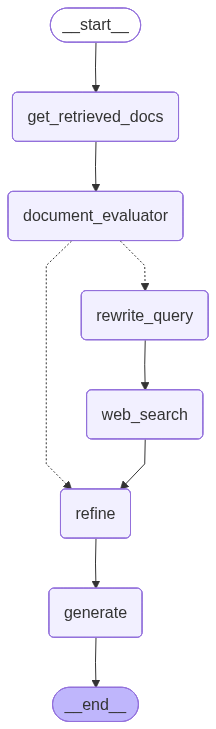

In [38]:
workflow=graph.compile()
workflow

In [39]:
result=workflow.invoke(
    {
    "question": "Word2Vec vs GloVe: Which embedding method is better for capturing semantic relationships in text data, and why?",
    }
)

C:\Users\miyas\AppData\Local\Temp\ipykernel_27440\453758266.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=WEB_SEARCH_RESULTS)


In [ ]:
result["answer"]

"To implement Word2Vec using GloVe for a given dataset, follow these steps:\n\n### 1. Data Preprocessing\n- **Convert Words to Indices**: Map each word in the vocabulary to an integer index based on a predefined list.\n- **Pad Words**: Ensure all words are of equal length by padding shorter words with zero vectors until they match the maximum vocabulary size.\n\n### 2. Construct Co-occurrence Matrix\n- **Initialize a Large Matrix**: Create a matrix `X` where `V` is the vocabulary size and each element `Xij` represents the co-occurrence count of word `j` around word `i`.\n- **Calculate Co-occurrences**:\n  - For each word `i`, consider its context words within the window size on either side.\n  - Increment `Xij` for each occurrence of word `j` around word `i`.\n\n### 3. Perform Matrix Factorization\n- **Decompose the Matrix**: Use matrix factorization techniques (e.g., SVD) to decompose the co-occurrence matrix `X` into two matrices:\n  - **Matrix A**: vocabulary matrix of size V x d, w

In [41]:
for chunk in workflow.stream({"question": "What is the role of LLM in AI?"}):
    print(chunk)
    print("---")

{'get_retrieved_docs': {'docs': [Document(id='d2f87203-e990-417a-9427-d66317cd1151', metadata={'source': 'D:\\Sixth Semester\\Conversational AI - Natural Language Processing\\Lectures\\Word Vectors-I.pdf'}, page_content='Word Vectors-I\n\n(Introduction,Word2Vec, Skipgram Model)\n\nDR. JASMEET SINGH,\n\nASSISTANT PROFESSOR,\n\nCSED, TIET\n\nWord meaning representation \uf0a7 Definition: meaning (Webster dictionary)\n\n\uf0a7 the idea that is represented by a word, phrase, etc. \uf0a7 the idea that a person wants to express by using words, signs, etc. \uf0a7 the idea that is represented in a work of writing, art, etc.\n\n\uf0a7Commonest linguistic way of thinking of meaning:\n\nsignifier (symbol) \uf0ab signified (idea or thing)\n\nHow do we have usable meaning in Computer?\n\nProblems with WordNet \uf0a7 Great as a resource but missing nuance\n\n\uf0a7 e.g., “proficient” is listed as a synonym for “good”; which is not correct in all\n\ncontexts.\n\n\uf0a7 Missing new meanings of words; 